## GeoShield.ai

In [19]:
import numpy
import pandas
import rasterio
import geopandas
import matplotlib
import sklearn
import streamlit
from geemap.common import ee_to_df
print("All libraries working! GeoShield is go 🚀")

All libraries working! GeoShield is go 🚀


In [2]:
import ee
ee.Initialize(project='geoshield-495409')
print("Earth Engine connected!")

Earth Engine connected!


In [3]:
import ee
import geemap

# Initialize
ee.Initialize(project='geoshield-495409')

# Define Jharia coalfield location
jharia = ee.Geometry.Rectangle([86.1, 23.6, 86.5, 23.9])

# Fetch Sentinel-2 data (2015 to 2026)
dataset = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(jharia) \
    .filterDate('2015-01-01', '2026-05-05') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)) \
    .median()

# Visualize on map
Map = geemap.Map()
Map.centerObject(jharia, 12)
Map.addLayer(dataset, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000}, 'Jharia RGB')
Map.addLayerControl()
Map

Map(center=[23.75007108059592, 86.3000000000006], controls=(WidgetControl(options=['position', 'transparent_bg…

In [4]:
# Calculate NDVI
ndvi = dataset.normalizedDifference(['B8', 'B4'])

# Add NDVI to map
Map.addLayer(ndvi, {
    'min': -1, 
    'max': 1, 
    'palette': ['red', 'yellow', 'green']
}, 'NDVI Jharia')

Map

Map(center=[23.75007108059592, 86.3000000000006], controls=(WidgetControl(options=['position', 'transparent_bg…

In [5]:
# NDVI 2017
ndvi_2017 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(jharia) \
    .filterDate('2017-01-01', '2018-01-01') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .median() \
    .normalizedDifference(['B8', 'B4'])

# NDVI 2025
ndvi_2025 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(jharia) \
    .filterDate('2025-01-01', '2026-01-01') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .median() \
    .normalizedDifference(['B8', 'B4'])

# NDVI Change (2017 to 2025)
ndvi_change = ndvi_2025.subtract(ndvi_2017)

# Add to map
Map.addLayer(ndvi_change, {
    'min': -0.5,
    'max': 0.5,
    'palette': ['red', 'white', 'green']
}, 'NDVI Change 2017-2025')

Map

Map(center=[23.75007108059592, 86.3000000000006], controls=(WidgetControl(options=['position', 'transparent_bg…

In [6]:
# Load Digital Elevation Model (DEM)
dem = ee.Image('USGS/SRTMGL1_003').clip(jharia)

# Visualize elevation
Map2 = geemap.Map()
Map2.centerObject(jharia, 12)
Map2.addLayer(dem, {
    'min': 150,
    'max': 400,
    'palette': ['blue', 'green', 'yellow', 'red']
}, 'Elevation')

Map2

Map(center=[23.75007108059592, 86.3000000000006], controls=(WidgetControl(options=['position', 'transparent_bg…

In [7]:
# Load rainfall data (ERA5 - 2017 to 2025)
rainfall = ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR') \
    .filterBounds(jharia) \
    .filterDate('2017-01-01', '2025-12-31') \
    .select('total_precipitation_sum') \
    .sum() \
    .clip(jharia)

# Add to map
Map2.addLayer(rainfall, {
    'min': 5,
    'max': 15,
    'palette': ['white', 'blue', 'darkblue']
}, 'Total Rainfall 2017-2025')

Map2

Map(center=[23.75007108059592, 86.3000000000006], controls=(WidgetControl(options=['position', 'transparent_bg…

In [8]:
ndvi_2017 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(jharia) \
    .filterDate('2017-01-01', '2018-01-01') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .median() \
    .normalizedDifference(['B8', 'B4']).rename('ndvi_2017')

ndvi_2025 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(jharia) \
    .filterDate('2025-01-01', '2026-01-01') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .median() \
    .normalizedDifference(['B8', 'B4']).rename('ndvi_2025')

ndvi_change = ndvi_2025.subtract(ndvi_2017).rename('ndvi_change')

dem = ee.Image('USGS/SRTMGL1_003').clip(jharia).rename('elevation')

rainfall = ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR') \
    .filterBounds(jharia) \
    .filterDate('2017-01-01', '2025-12-31') \
    .select('total_precipitation_sum') \
    .sum() \
    .clip(jharia).rename('rainfall')

combined = ndvi_change.addBands(dem).addBands(rainfall).addBands(ndvi_2025)

print("Combined image bands:", combined.bandNames().getInfo())

Combined image bands: ['ndvi_change', 'elevation', 'rainfall', 'ndvi_2025']


In [9]:
# Known collapse/subsidence points in Jharia (lat, lon, label)
collapse_points = [
    # Collapse locations (label = 1)
    (23.75, 86.22, 1),  # Jharia town subsidence
    (23.78, 86.25, 1),  # Bararee collapse
    (23.72, 86.20, 1),  # Kusunda mine
    (23.80, 86.28, 1),  # Katras colliery
    (23.77, 86.30, 1),  # Govindpur subsidence
    (23.74, 86.18, 1),  # Bastacolla
    (23.76, 86.32, 1),  # Sijua
    (23.70, 86.23, 1),  # Lodna colliery
    (23.82, 86.26, 1),  # Dhanbad subsidence
    (23.73, 86.29, 1),  # Moonidih mine
    
    # Safe locations (label = 0)
    (23.65, 86.15, 0),  # Safe zone south
    (23.85, 86.35, 0),  # Safe zone north
    (23.63, 86.30, 0),  # Safe zone east
    (23.87, 86.18, 0),  # Safe zone west
    (23.68, 86.12, 0),  # Rural safe area
    (23.90, 86.22, 0),  # Forest area
    (23.62, 86.25, 0),  # Agricultural zone
    (23.88, 86.32, 0),  # Safe north east
    (23.66, 86.38, 0),  # Safe east
    (23.84, 86.14, 0),  # Safe west
]

print(f"Total points: {len(collapse_points)}")
print(f"Collapse points: {sum(1 for p in collapse_points if p[2]==1)}")
print(f"Safe points: {sum(1 for p in collapse_points if p[2]==0)}")

Total points: 20
Collapse points: 10
Safe points: 10


In [10]:
# Convert to EE feature collection
features = []
for lat, lon, label in collapse_points:
    point = ee.Geometry.Point([lon, lat])
    feature = ee.Feature(point, {'label': label})
    features.append(feature)

fc = ee.FeatureCollection(features)

# Combined bands (run again to make sure)
ndvi_2017 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(jharia) \
    .filterDate('2017-01-01', '2018-01-01') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .median() \
    .normalizedDifference(['B8', 'B4']).rename('ndvi_2017')

ndvi_2025 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(jharia) \
    .filterDate('2025-01-01', '2026-01-01') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .median() \
    .normalizedDifference(['B8', 'B4']).rename('ndvi_2025')

ndvi_change = ndvi_2025.subtract(ndvi_2017).rename('ndvi_change')
dem = ee.Image('USGS/SRTMGL1_003').clip(jharia).rename('elevation')
rainfall = ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR') \
    .filterBounds(jharia) \
    .filterDate('2017-01-01', '2025-12-31') \
    .select('total_precipitation_sum') \
    .sum().clip(jharia).rename('rainfall')

combined = ndvi_change.addBands(dem).addBands(rainfall).addBands(ndvi_2025)

# Sample values at each point
sampled = combined.sampleRegions(
    collection=fc,
    scale=30,
    geometries=True
)

# Convert to pandas dataframe
df = geemap.ee_to_df(sampled, remove_geom=False)
df = df.drop(columns=['geo']) if 'geo' in df.columns else df
print(df.head())
print(df.shape)

   elevation  label  ndvi_2025  ndvi_change   rainfall
0        204      1   0.440948    -0.001818  12.072989
1        210      1   0.231451    -0.010955  11.703615
2        175      1   0.583856     0.114618  12.072989
3        205      1   0.175375     0.025549  11.754498
4        191      1   0.495779     0.041681  11.754498
(20, 5)


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Features aur labels alag karo
X = df[['ndvi_change', 'elevation', 'rainfall', 'ndvi_2025']]
y = df['label']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model train karo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



Model saved!


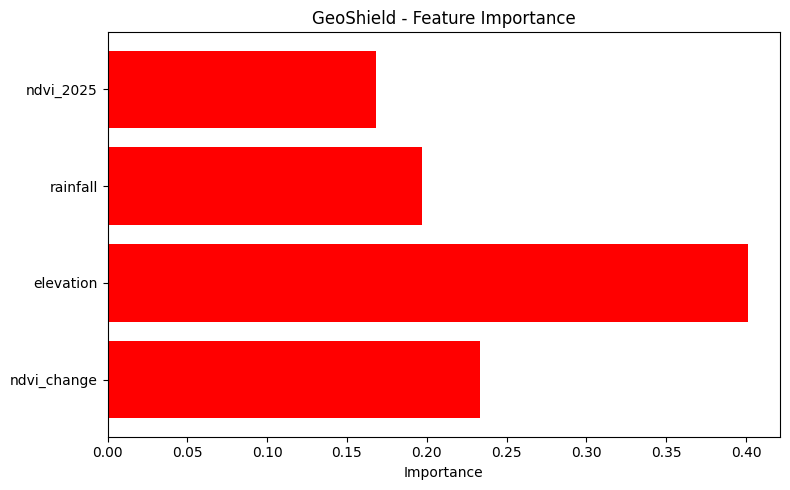

In [12]:
import joblib

# Model save karo
joblib.dump(model, 'geoshield_model.pkl')
print("Model saved!")

# Feature importance dekho
import matplotlib.pyplot as plt

features = ['ndvi_change', 'elevation', 'rainfall', 'ndvi_2025']
importance = model.feature_importances_

plt.figure(figsize=(8, 5))
plt.barh(features, importance, color='red')
plt.xlabel('Importance')
plt.title('GeoShield - Feature Importance')
plt.tight_layout()
plt.show()

In [13]:
# Rebuild combined image
ndvi_2017 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(jharia) \
    .filterDate('2017-01-01', '2018-01-01') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .median() \
    .normalizedDifference(['B8', 'B4']).rename('ndvi_2017')

ndvi_2025 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(jharia) \
    .filterDate('2025-01-01', '2026-01-01') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .median() \
    .normalizedDifference(['B8', 'B4']).rename('ndvi_2025')

ndvi_change = ndvi_2025.subtract(ndvi_2017).rename('ndvi_change')
dem = ee.Image('USGS/SRTMGL1_003').clip(jharia).rename('elevation')
rainfall = ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR') \
    .filterBounds(jharia) \
    .filterDate('2017-01-01', '2025-12-31') \
    .select('total_precipitation_sum') \
    .sum().clip(jharia).rename('rainfall')

combined = ndvi_change.addBands(dem).addBands(rainfall).addBands(ndvi_2025)

# Sample 500 random points across Jharia
random_points = combined.sample(
    region=jharia,
    scale=100,
    numPixels=500,
    seed=42,
    geometries=True
)

# Convert to dataframe
df_map = geemap.ee_to_df(random_points, remove_geom=False)
df_map = df_map.drop(columns=['geo']) if 'geo' in df_map.columns else df_map

print(df_map.shape)
print(df_map.head())

(500, 4)
   elevation  ndvi_2025  ndvi_change   rainfall
0        233   0.476087    -0.010927  11.703615
1        242   0.385111    -0.024144  11.754498
2        186   0.486083    -0.021335  12.072989
3        197   0.547511     0.066015  12.061605
4        164   0.346167     0.075659  12.377106


In [14]:
# Predict risk for all 500 points
X_map = df_map[['ndvi_change', 'elevation', 'rainfall', 'ndvi_2025']]
df_map['risk'] = model.predict_proba(X_map)[:, 1]

# Get coordinates
coords = random_points.getInfo()['features']
lats = [f['geometry']['coordinates'][1] for f in coords]
lons = [f['geometry']['coordinates'][0] for f in coords]

df_map['lat'] = lats
df_map['lon'] = lons

print(df_map[['lat', 'lon', 'risk']].head(10))
print("\nHigh risk points:", (df_map['risk'] > 0.5).sum())
print("Low risk points:", (df_map['risk'] <= 0.5).sum())

         lat        lon  risk
0  23.807212  86.213881  0.33
1  23.833895  86.345360  0.35
2  23.714800  86.217680  0.85
3  23.745015  86.270834  0.77
4  23.633940  86.326356  0.32
5  23.702169  86.133215  0.64
6  23.800178  86.373812  0.46
7  23.849561  86.342861  0.26
8  23.723929  86.361620  0.47
9  23.829675  86.349270  0.46

High risk points: 213
Low risk points: 287


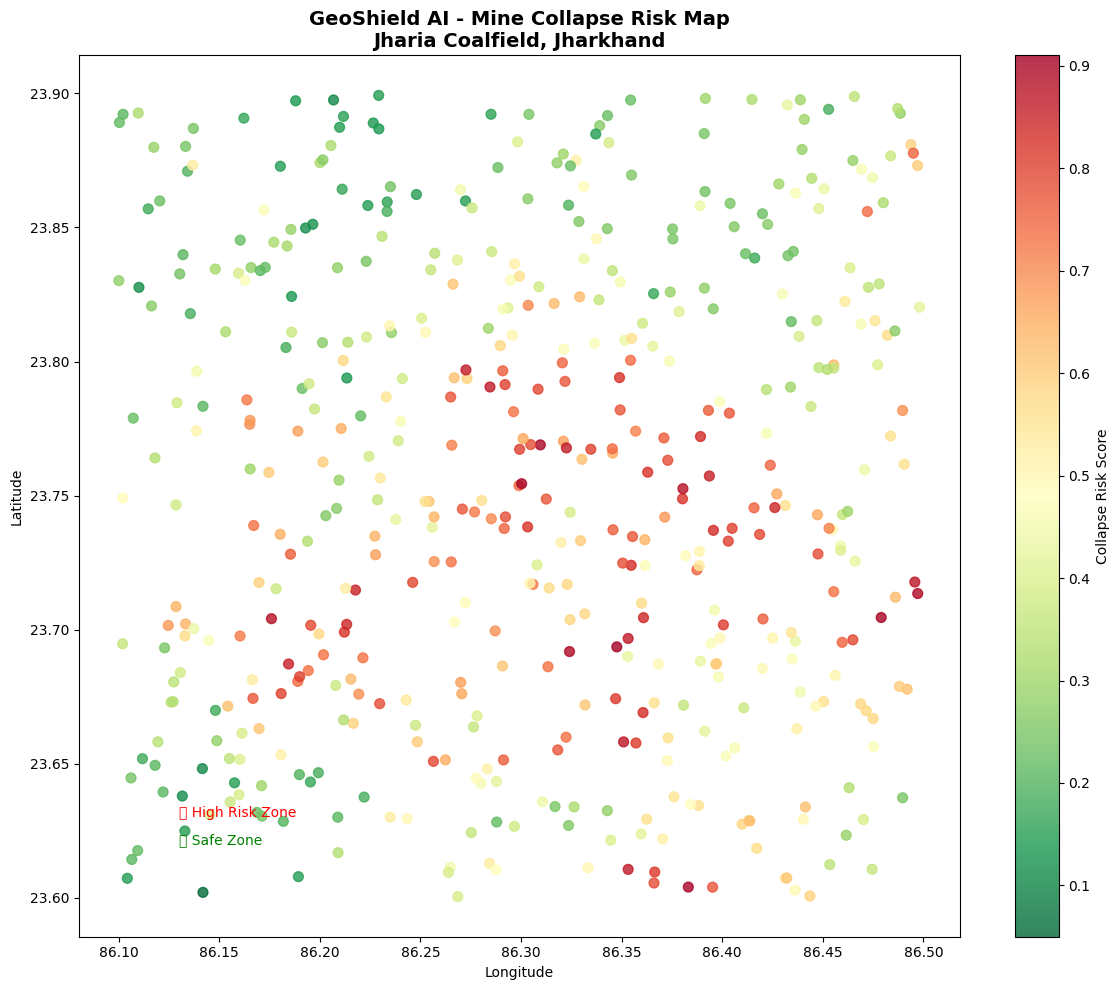

Risk map saved!


In [15]:
# Plot risk map
plt.figure(figsize=(12, 10))

scatter = plt.scatter(
    df_map['lon'], 
    df_map['lat'], 
    c=df_map['risk'], 
    cmap='RdYlGn_r',  # Red = high risk, Green = safe
    s=50, 
    alpha=0.8
)

plt.colorbar(scatter, label='Collapse Risk Score')
plt.title('GeoShield AI - Mine Collapse Risk Map\nJharia Coalfield, Jharkhand', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Add risk zones text
plt.text(86.13, 23.63, '🔴 High Risk Zone', fontsize=10, color='red')
plt.text(86.13, 23.62, '🟢 Safe Zone', fontsize=10, color='green')

plt.tight_layout()
plt.savefig('geoshield_risk_map.png', dpi=150)
plt.show()

print("Risk map saved!")

In [16]:
# Detect fire/heat zones using Landsat thermal band
landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filterBounds(jharia) \
    .filterDate('2020-01-01', '2025-12-31') \
    .filter(ee.Filter.lt('CLOUD_COVER', 20)) \
    .median()

# Thermal band (ST_B10) = surface temperature
thermal = landsat.select('ST_B10') \
    .multiply(0.00341802) \
    .add(149.0) \
    .subtract(273.15) \
    .rename('temperature')

# High temperature = fire zone proxy
# Jharia underground fires cause surface temp anomalies
Map3 = geemap.Map()
Map3.centerObject(jharia, 12)
Map3.addLayer(thermal, {
    'min': 20,
    'max': 50,
    'palette': ['blue', 'green', 'yellow', 'red']
}, 'Surface Temperature')

Map3

Map(center=[23.75007108059592, 86.3000000000006], controls=(WidgetControl(options=['position', 'transparent_bg…

In [17]:
# Add temperature as feature
landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filterBounds(jharia) \
    .filterDate('2020-01-01', '2025-12-31') \
    .filter(ee.Filter.lt('CLOUD_COVER', 20)) \
    .median()

temperature = landsat.select('ST_B10') \
    .multiply(0.00341802) \
    .add(149.0) \
    .subtract(273.15) \
    .rename('temperature')

# Add to combined image
combined_v2 = combined.addBands(temperature)
print("New bands:", combined_v2.bandNames().getInfo())

New bands: ['ndvi_change', 'elevation', 'rainfall', 'ndvi_2025', 'temperature']


In [20]:
# Sample points with new combined_v2
random_points_v2 = combined_v2.sample(
    region=jharia,
    scale=100,
    numPixels=20,
    seed=42,
    geometries=True
)

# Known collapse points with labels
features = []
for lat, lon, label in collapse_points:
    point = ee.Geometry.Point([lon, lat])
    feature = ee.Feature(point, {'label': label})
    features.append(feature)

fc = ee.FeatureCollection(features)

# Sample new features at collapse points
sampled_v2 = combined_v2.sampleRegions(
    collection=fc,
    scale=30,
    geometries=True
)

df_v2 = ee_to_df(sampled_v2, remove_geom=False)
df_v2 = df_v2.drop(columns=['geo']) if 'geo' in df_v2.columns else df_v2

print(df_v2.head())
print(df_v2.shape)

   elevation  label  ndvi_2025  ndvi_change   rainfall  temperature
0        204      1   0.440948    -0.001818  12.072989    29.997575
1        210      1   0.231451    -0.010955  11.703615    32.474215
2        175      1   0.583856     0.114618  12.072989    29.097781
3        205      1   0.175375     0.025549  11.754498    35.710795
4        191      1   0.495779     0.041681  11.754498    28.606441
(20, 6)


GeoShield 2.0 Accuracy: 1.0


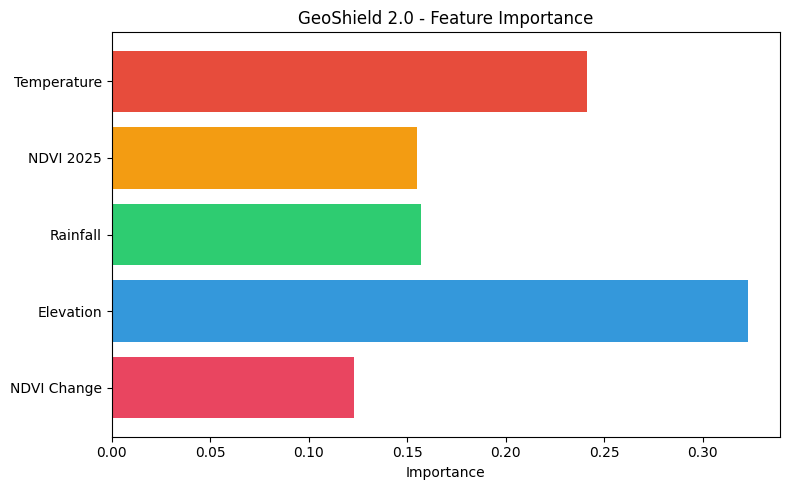

GeoShield 2.0 model saved!


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib

# New features with temperature
X_v2 = df_v2[['ndvi_change', 'elevation', 'rainfall', 'ndvi_2025', 'temperature']]
y_v2 = df_v2['label']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

# Train new model
model_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v2.fit(X_train, y_train)

# Evaluate
y_pred = model_v2.predict(X_test)
print("GeoShield 2.0 Accuracy:", accuracy_score(y_test, y_pred))

# Feature importance
import matplotlib.pyplot as plt
features = ['NDVI Change', 'Elevation', 'Rainfall', 'NDVI 2025', 'Temperature']
importance = model_v2.feature_importances_

plt.figure(figsize=(8, 5))
plt.barh(features, importance, color=['#e94560', '#3498db', '#2ecc71', '#f39c12', '#e74c3c'])
plt.xlabel('Importance')
plt.title('GeoShield 2.0 - Feature Importance')
plt.tight_layout()
plt.show()

# Save new model
joblib.dump(model_v2, 'geoshield_v2_model.pkl')
print("GeoShield 2.0 model saved!")